In [1]:
%matplotlib inline
import numpy as np
from monodromy.haar import expected_cost, gates_to_haar
from monodromy.render import gates_to_coverage_plot
from weylchamber import WeylChamber, c1c2c3
from hetero_isas.zz_parallel_drive.hamiltonian import ZZ_ParallelDrive
from qiskit.circuit.library import iSwapGate, CZGate, CXGate
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate
from monodromy.coverage import gates_to_coverage
import matplotlib.pyplot as plt
from tqdm import tqdm

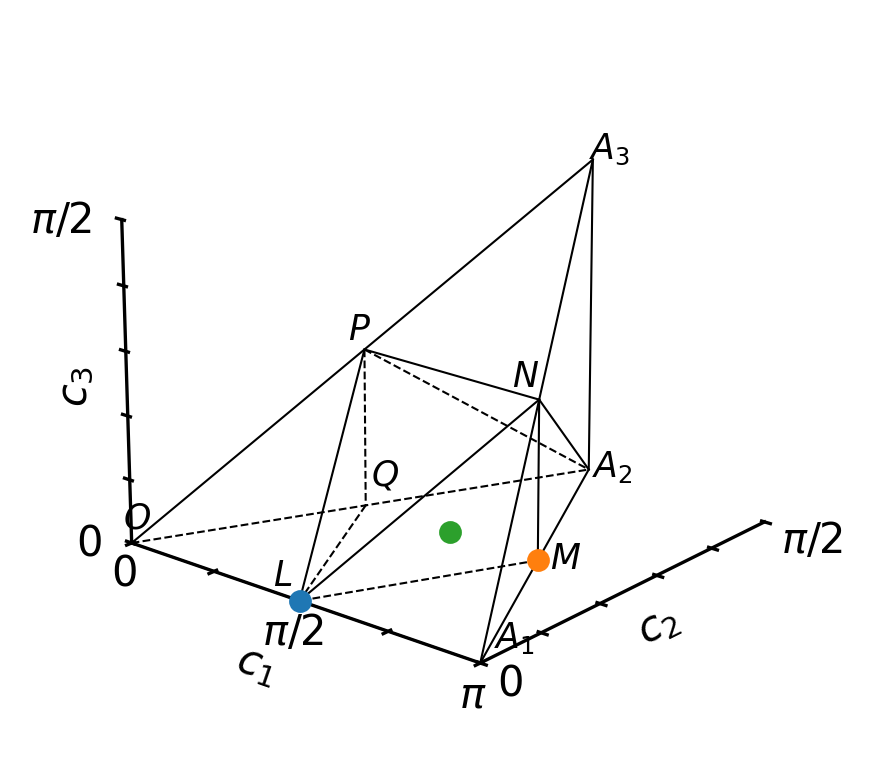

In [29]:
# testing heterogeneous sets
# isa_set = [CZGate, ~sqrt{iSWAP}, ~BGate]
isa_params = [(np.pi / 2, 0), (np.pi / 2, 3.04211577), (3 * np.pi / 4, np.pi**2 / 5)]
unit_costs = [zz_rate / isa_params[0][0] for zz_rate, xi_rate in isa_params]
isa_set = []

for zz_rate, xi_rate in isa_params:
    H = ZZ_ParallelDrive(g_zz=zz_rate, g_xi=xi_rate, g_ix=xi_rate)
    U = H.to_unitary(t=1)
    U.name = f"({zz_rate}, {xi_rate})"  # needs to look unique for monodromy coverage
    isa_set.append(U)

w = WeylChamber()
for gate in isa_set:
    w.scatter(*c1c2c3(gate))
w.plot()

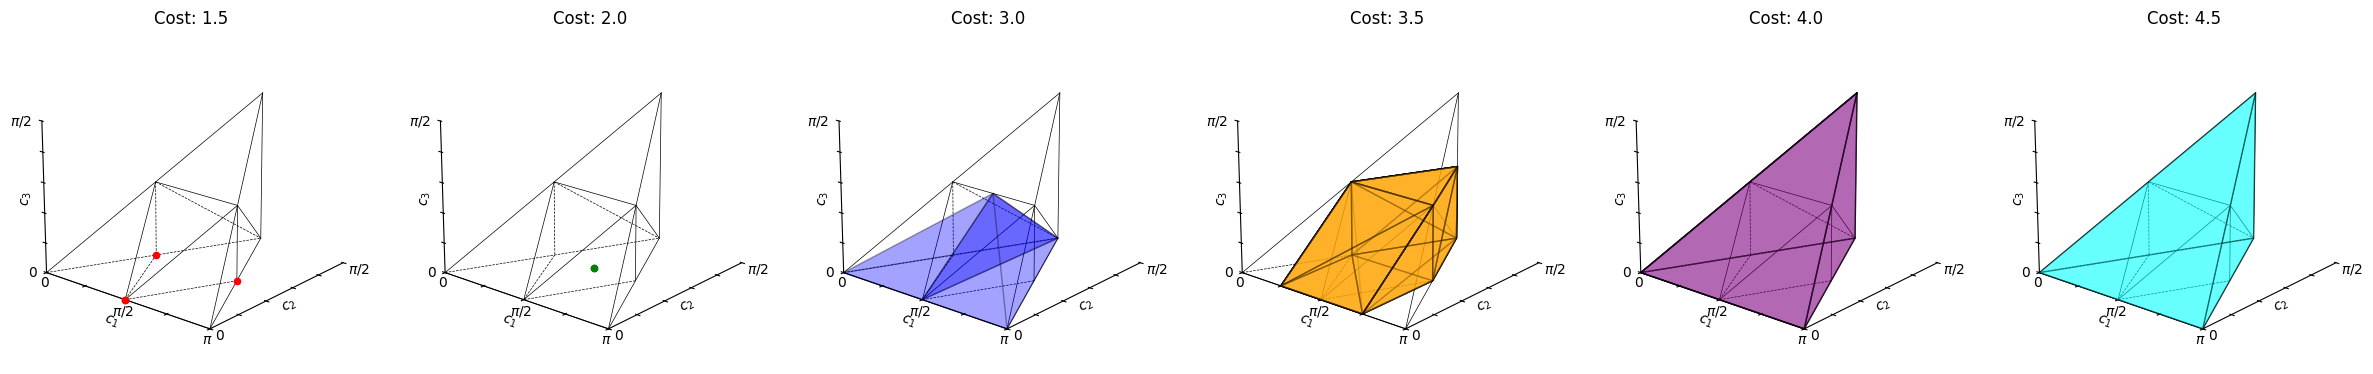

3.112414559477982

In [30]:
# coverage = gates_to_coverage_plot(iSwapGate().power(1 / 2), single_qubit_cost=0.25)
# expected_cost(coverage)

# coverage = gates_to_coverage_plot(CXGate().power(1 / 2))
# expected_cost(coverage)

coverage = gates_to_coverage_plot(*isa_set, costs=unit_costs, single_qubit_cost=0.5)
expected_cost(coverage)

In [31]:
# isa_params = (np.pi / 2, 3.04211577)
# H = ZZ_ParallelDrive(g_zz=isa_params[0], g_xi=isa_params[1], g_ix=isa_params[1])
# U = H.to_unitary(t=1)
# c1c2c3(U)

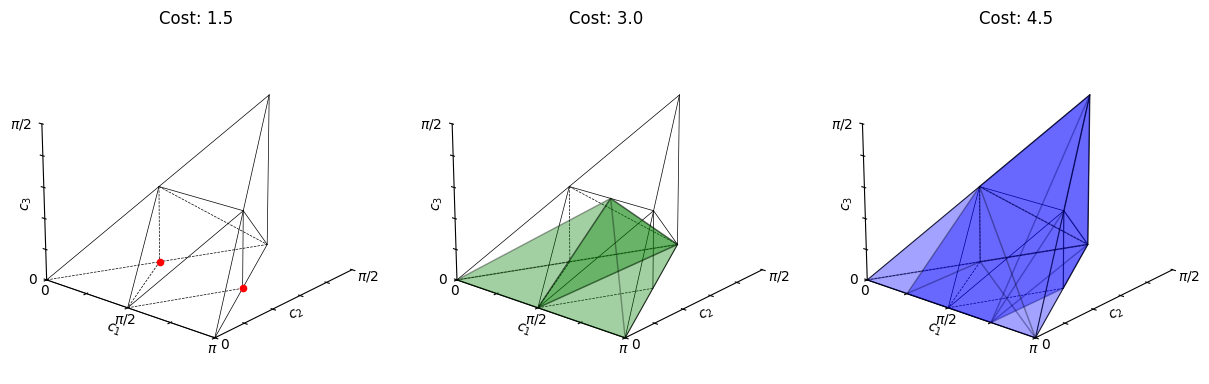

3.314823954473516

In [33]:
coverage = gates_to_coverage_plot(
    iSwapGate().power(1 / 2), costs=[1], single_qubit_cost=0.5
)
expected_cost(coverage)

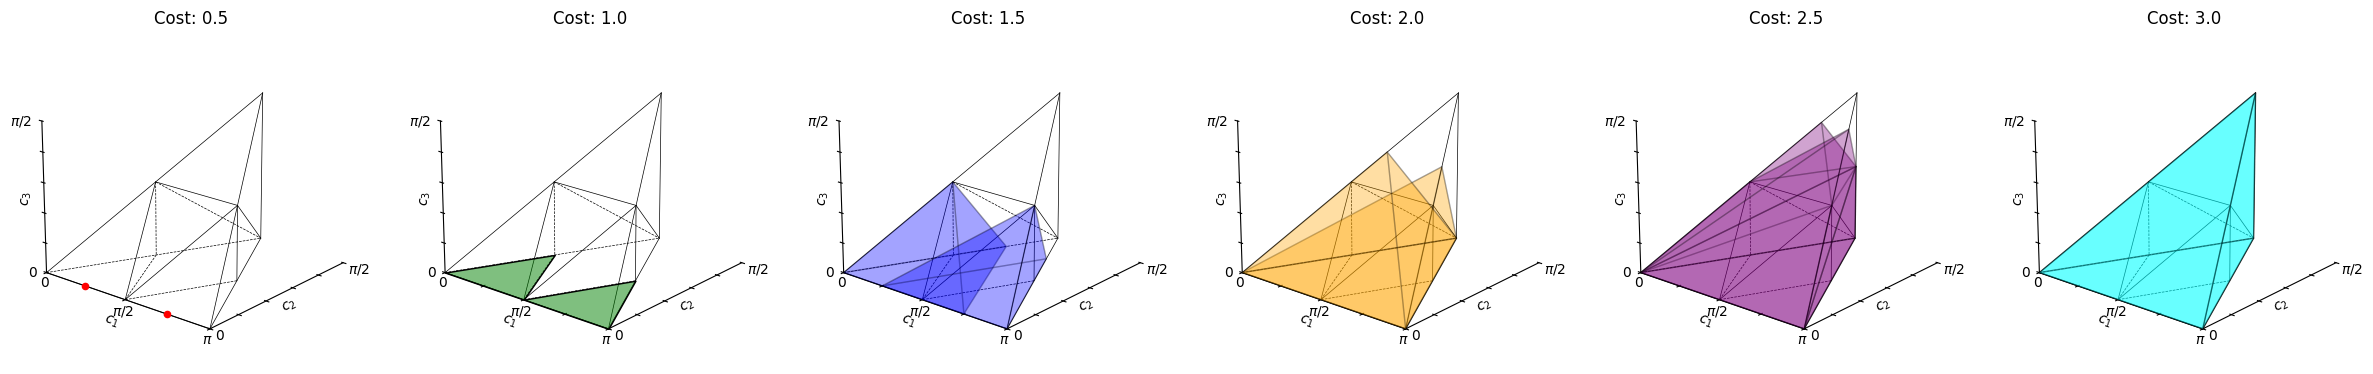

1.7701274104040134

In [4]:
coverage = gates_to_coverage_plot(
    CXGate().power(1 / 2), costs=[1 / 2], single_qubit_cost=0
)
expected_cost(coverage)

In [1]:
coverage = gates_to_coverage_plot(
    iSwapGate().power(1 / 4), costs=[0.25], single_qubit_cost=0.5
)
expected_cost(coverage)

NameError: name 'gates_to_coverage_plot' is not defined

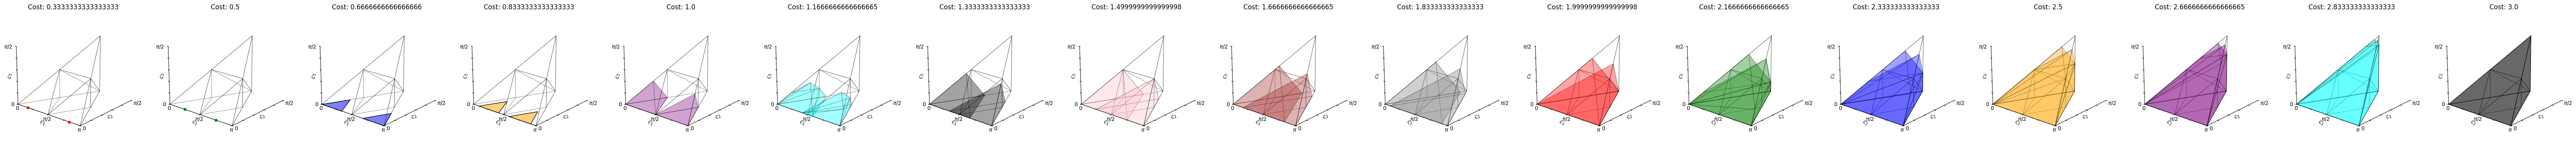

1.5852968488391417

In [6]:
from qiskit.circuit.library import CPhaseGate

coverage = gates_to_coverage_plot(
    CPhaseGate(np.pi),
    CPhaseGate(np.pi / 2),
    CPhaseGate(np.pi / 3),
    # costs=[1, 1 / 2, 1 / 3],
    costs=[
        1,
        1 / 2,
        1 / 3,
    ],
    # single_qubit_cost=0.5,
)
expected_cost(coverage)

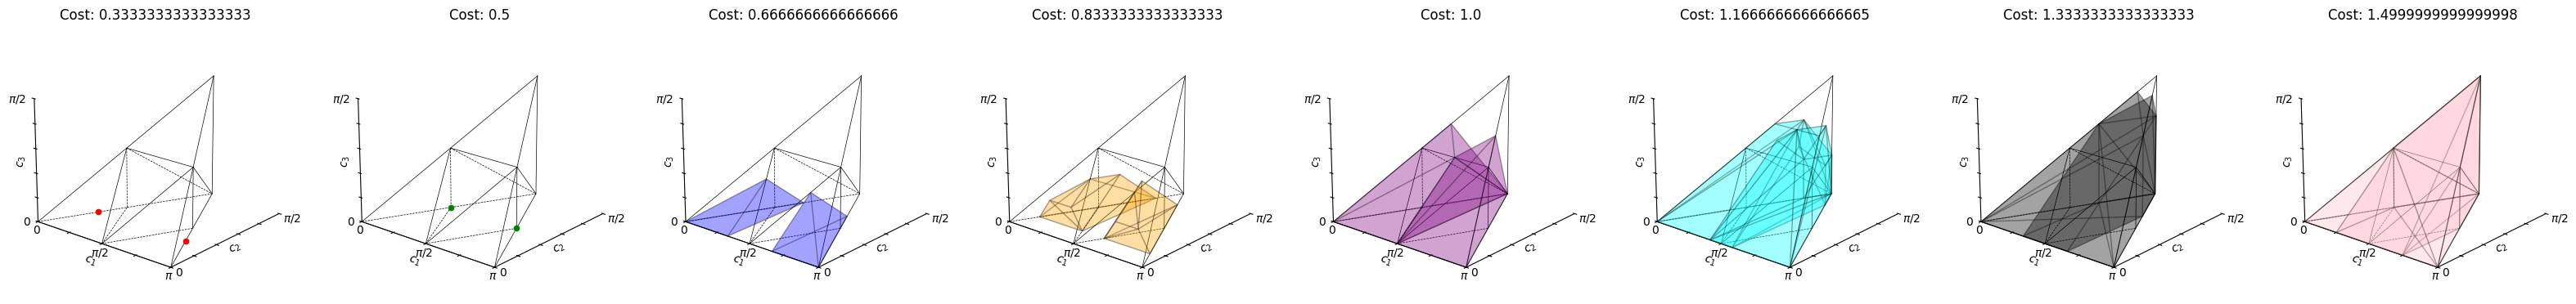

np.float64(0.9484185085810612)

In [8]:
coverage = gates_to_coverage_plot(
    iSwapGate(),
    iSwapGate().power(1 / 2),
    iSwapGate().power(1 / 3),
    # iSwapGate().power(1 / 4),
    costs=[1, 1 / 2, 1 / 3],
    # single_qubit_cost=0.5,
)
expected_cost(coverage)

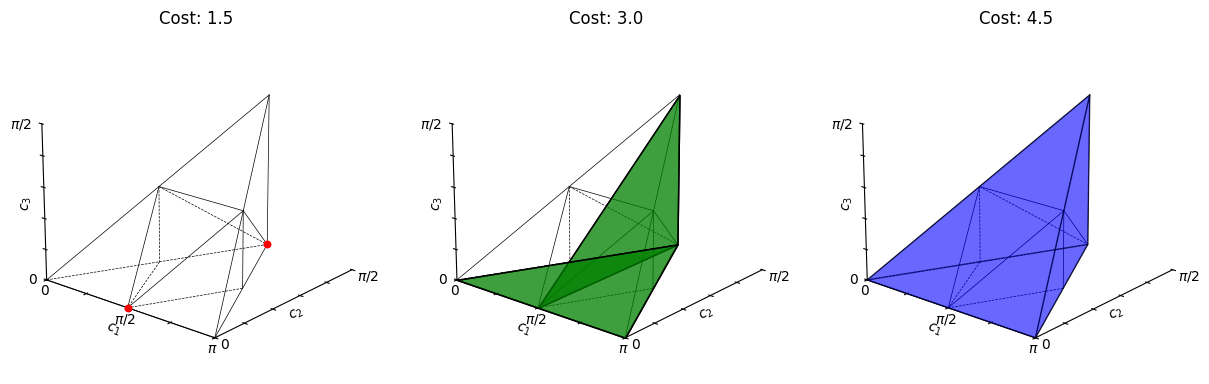

4.500000000000001

In [37]:
coverage = gates_to_coverage_plot(
    iSwapGate(),
    CZGate(),
    costs=[1, 1],
    single_qubit_cost=0.5,
)
expected_cost(coverage)

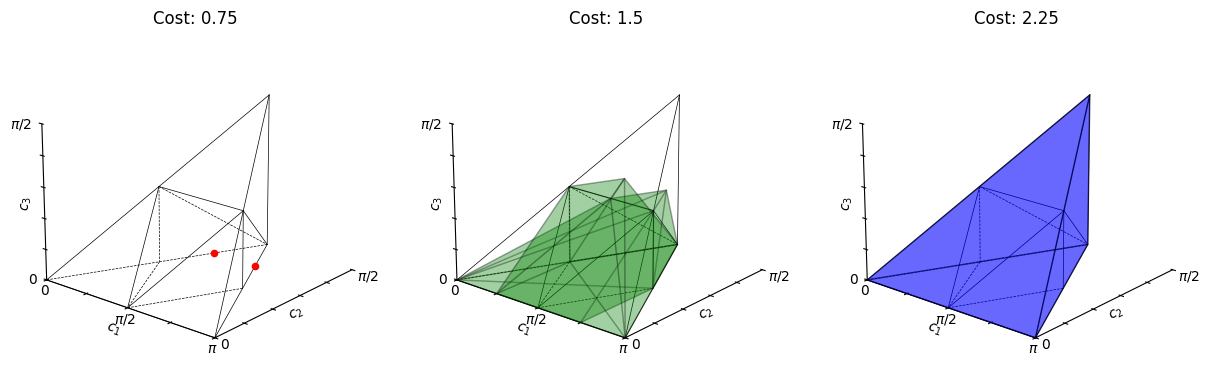

1.5340668963405397

In [38]:
coverage = gates_to_coverage_plot(
    iSwapGate().power(3 / 4),
    costs=[0.75],
    single_qubit_cost=0,
)
expected_cost(coverage)

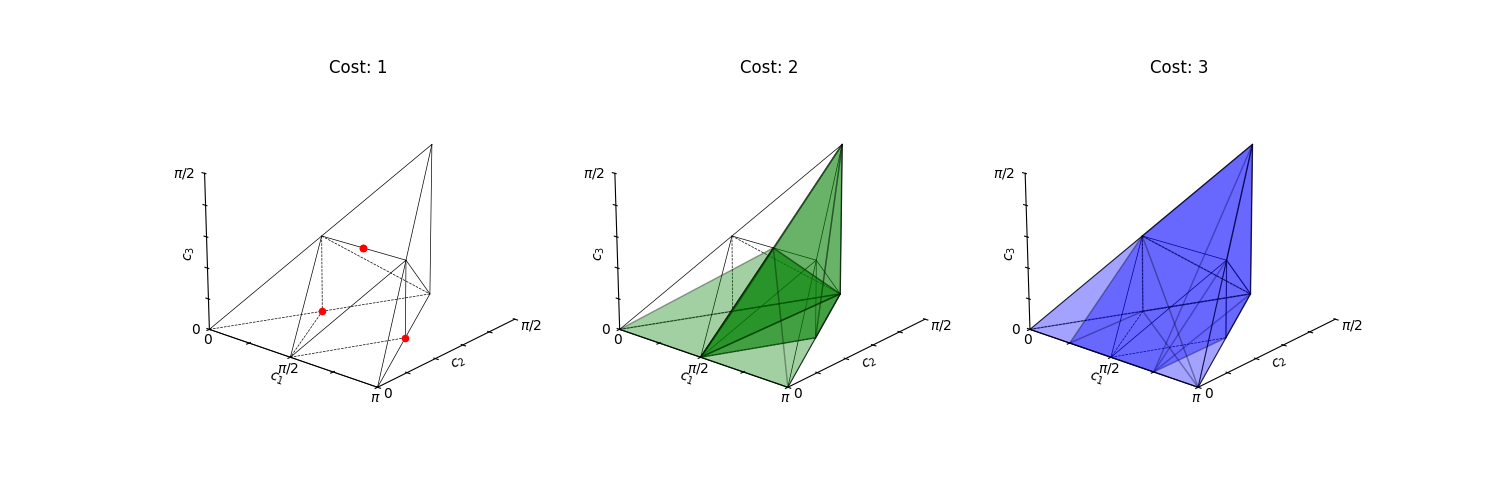

2.0563850449989367

In [7]:
%matplotlib widget
from weylchamber import c1c2c3
from qiskit.circuit.library import iSwapGate, SwapGate
from qiskit.quantum_info import Operator

qc = QuantumCircuit(2)
qc.append(iSwapGate().power(1 / 2), [0, 1])
qc.append(SwapGate(), [0, 1])
ecp = UnitaryGate(Operator(qc).data)

coverage = gates_to_coverage_plot(
    iSwapGate().power(1 / 2),
    ecp,
    costs=[1, 1],
    single_qubit_cost=0,
)
expected_cost(coverage)

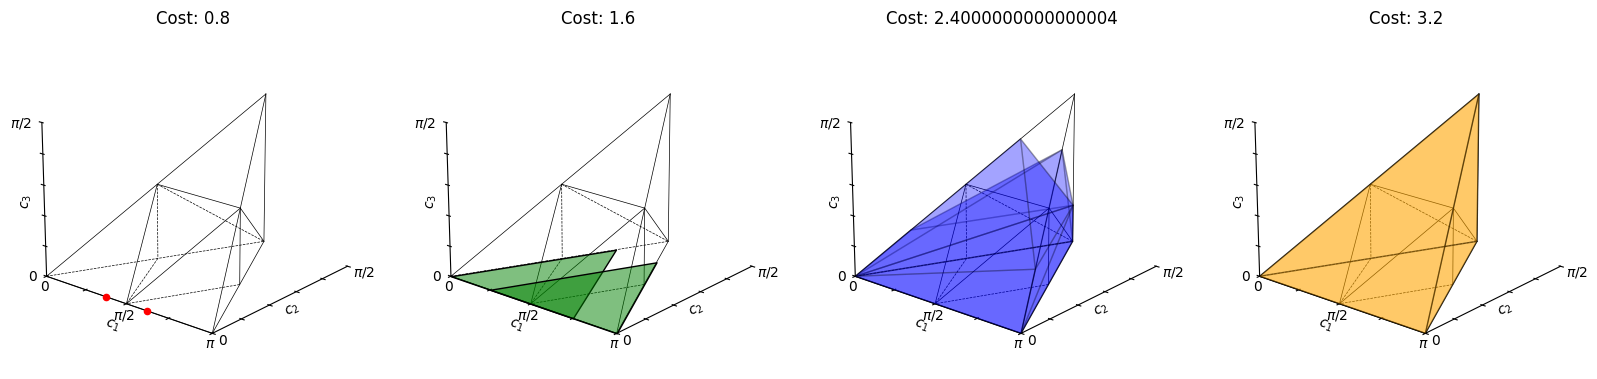

np.float64(2.4033516525751275)

In [11]:
coverage = gates_to_coverage_plot(
    CXGate().power(0.75),
    costs=[0.8],
    single_qubit_cost=0,
)
expected_cost(coverage)

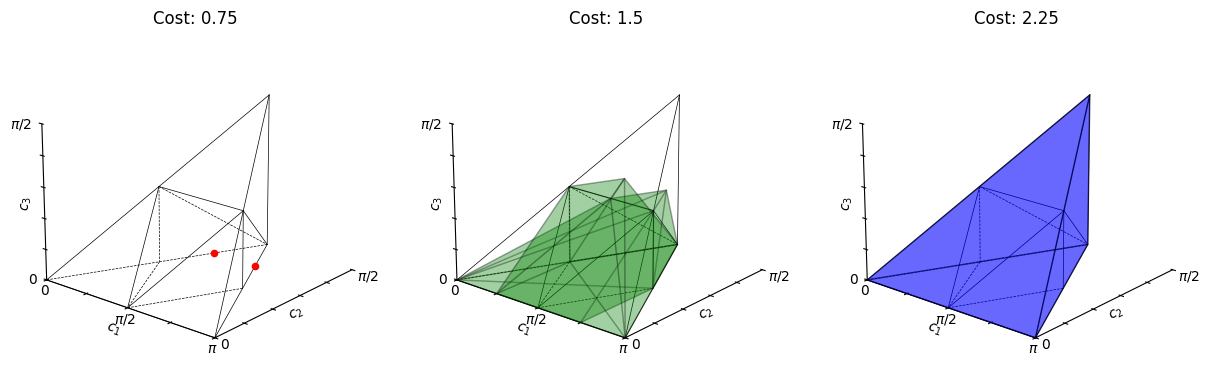

np.float64(1.5340668963405397)

In [12]:
coverage = gates_to_coverage_plot(
    iSwapGate().power(0.5),
    costs=[0.75],
    single_qubit_cost=0,
)
expected_cost(coverage)

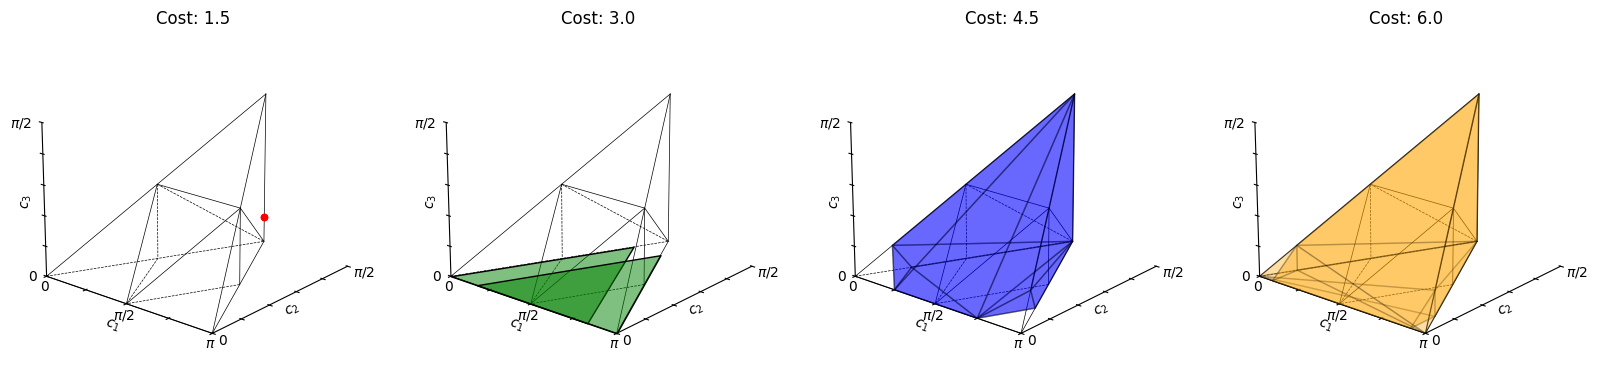

4.500206185685554

In [41]:
fsim = QuantumCircuit(2)
fsim.iswap(0, 1)
fsim.cp(np.pi / 6, 0, 1)
fsim = Operator(fsim).data
coverage = gates_to_coverage_plot(UnitaryGate(fsim), costs=[1], single_qubit_cost=0.5)
expected_cost(coverage)

In [3]:
# def slow_cost(frac, single_q):
#     coverage_set = gates_to_coverage(
#         iSwapGate().power(frac),
#         costs=[frac],
#         single_qubit_cost=single_q,
#     )
#     return expected_cost(coverage_set)
# NOTE this is way overly expensive to compute for different 1Q costs
# instead could just calculate the offset
# assume each gate has cost of 1, then we can convert # of gate applications into scaled cost
# however this method could be better if have more complex ISA with varying costs that need to be considered
# XXX


def simple_cost(frac):
    coverage_set = gates_to_coverage(
        iSwapGate().power(frac),
        costs=[1],
        single_qubit_cost=0,
    )
    expected_num = expected_cost(coverage_set)
    return expected_num
    # return expected_num * (frac + single_q) + single_q


frac = np.geomspace(1, 1 / 16, 32)
single_q_costs = [0, 0.1, 0.25, 0.5]
basic_costs = [simple_cost(f) for f in tqdm(frac)]  # expensive part

  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [11:06<00:00, 20.84s/it]


min expected cost for c(1q)=0: 0.8837 at frac=0.0625
min expected cost for c(1q)=0.1: 1.4015 at frac=0.3419
min expected cost for c(1q)=0.25: 1.9395 at frac=0.4889
min expected cost for c(1q)=0.5: 2.7611 at frac=0.4889


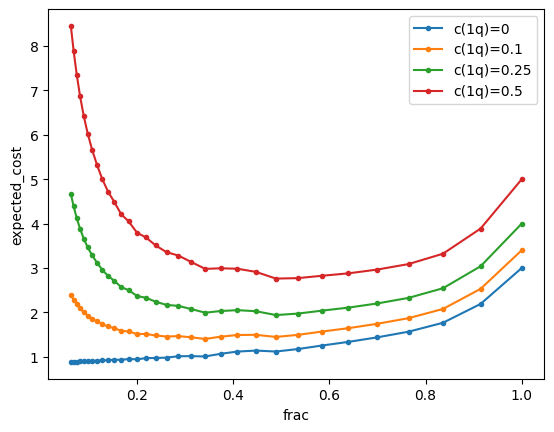

In [ ]:
def adjust(single_q):
    return basic_costs * (frac + single_q) + single_q


adjusted_costs = [adjust(single_q) for single_q in single_q_costs]
for single_q, adjusted_cost in zip(single_q_costs, adjusted_costs):
    plt.plot(
        frac,
        adjusted_cost,
        marker=".",
        label=f"c(1q)={single_q}",
    )

    min_index = np.argmin(adjusted_cost)
    min_value = adjusted_cost[min_index]
    min_frac = frac[min_index]
    print(
        f"min expected cost for c(1q)={single_q}: {min_value:.4f} at frac={min_frac:.4f}"
    )

plt.xlabel("frac")
plt.ylabel("expected_cost")
plt.legend()
plt.show()

In [ ]:
# theorem 55
def xy_volume(alpha):
    t = alpha / np.pi
    if t <= 0.5:
        return 4 * t**3
    elif t <= 0.75:
        return 7.5 - 36 * t + 60 * t**2 - 32 * t**3
    elif t <= 1:
        return -6 + 18 * t - 12 * t**2


plot()

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [02:08<00:00, 12.87s/it]


Text(0, 0.5, 'expected cost')

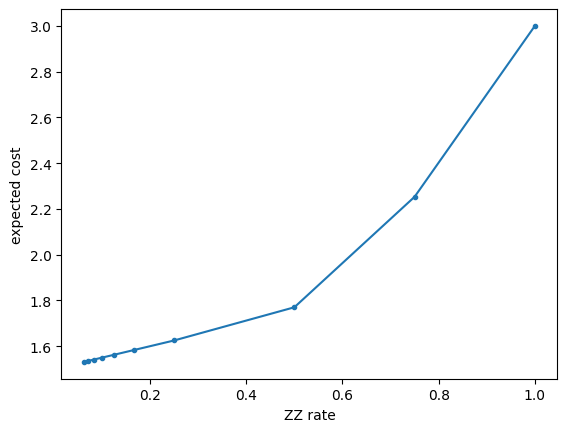

In [13]:
def variable_fsim(zz_rate):
    fsim = QuantumCircuit(2)
    # fsim.append(iSwapGate().power(1 / 2), [0, 1])
    # fsim.iswap(0, 1)
    # fsim.cp(np.pi / 6, 0, 1)
    fsim.cp(zz_rate, 0, 1)
    fsim = Operator(fsim).data
    coverage = gates_to_coverage(
        UnitaryGate(fsim), costs=[zz_rate / np.pi], single_qubit_cost=0.0
    )
    return expected_cost(coverage)


zz_list = [
    np.pi,
    3 * np.pi / 4,
    np.pi / 2,
    np.pi / 4,
    np.pi / 6,
    np.pi / 8,
    np.pi / 10,
    np.pi / 12,
    np.pi / 14,
    np.pi / 16,
    # 0,
]
# variable_fsim(np.pi / 6)
costs = [variable_fsim(zz) for zz in tqdm(zz_list)]
plt.plot(np.array(zz_list) / np.pi, costs, marker=".")
plt.xlabel("ZZ rate")
plt.ylabel("expected cost")